# 05 Tree Models: Decision Tree, Random Forest, and Gradient Boosting

## Loan Default Prediction and Credit Risk Scorecard

This notebook builds non-linear machine learning models for loan default prediction. It compares decision tree, random forest, and gradient boosting models against the logistic regression benchmark.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/processed/loan_modeling_dataset.csv")

df.shape

(1369566, 37)

In [3]:
df["default_flag"].value_counts(normalize=True).mul(100).round(2)

default_flag
0    78.77
1    21.23
Name: proportion, dtype: float64

In [4]:
target = "default_flag"

drop_cols = [
    "funded_amnt"
]

drop_cols = [col for col in drop_cols if col in df.columns]

X = df.drop(columns=[target] + drop_cols)
y = df[target]

X.shape, y.shape

((1369566, 35), (1369566,))

`funded_amnt` is highly related to `loan_amnt`. Removing it improves feature clarity and reduces redundancy.

In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 26
['loan_amnt', 'term_months', 'int_rate', 'installment', 'grade_risk_numeric', 'emp_length_years', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'issue_year', 'issue_month', 'credit_history_months', 'loan_income_ratio', 'installment_income_ratio', 'high_dti_flag', 'high_revol_util_flag', 'recent_inquiry_flag', 'long_term_flag']

Categorical features: 9
['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'application_type', 'income_band', 'dti_band', 'credit_history_band']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train default rate:", y_train.mean().round(4))
print("Test default rate:", y_test.mean().round(4))

X_train: (1027174, 35)
X_test: (342392, 35)
Train default rate: 0.2123
Test default rate: 0.2124


In [7]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [8]:
def evaluate_classifier(model_name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

In [9]:
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=500,
        class_weight="balanced",
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

decision_tree_probs = decision_tree_model.predict_proba(X_test)[:, 1]

decision_tree_results = evaluate_classifier(
    "Decision Tree",
    y_test,
    decision_tree_probs,
    threshold=0.5
)

decision_tree_results

{'model': 'Decision Tree',
 'threshold': 0.5,
 'roc_auc': 0.7059893530240071,
 'pr_auc': 0.3783315311283181,
 'accuracy': 0.6645832846561835,
 'precision': 0.3412787500282509,
 'recall': 0.6230624286519867,
 'f1_score': 0.44100152838215395}

In [10]:
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_leaf=200,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

random_forest_probs = random_forest_model.predict_proba(X_test)[:, 1]

random_forest_results = evaluate_classifier(
    "Random Forest",
    y_test,
    random_forest_probs,
    threshold=0.5
)

random_forest_results

{'model': 'Random Forest',
 'threshold': 0.5,
 'roc_auc': 0.7133513000881408,
 'pr_auc': 0.3966304756345388,
 'accuracy': 0.6372140704222061,
 'precision': 0.3293103219734627,
 'recall': 0.6833867440549053,
 'f1_score': 0.4444494138799315}

In [11]:
gradient_boosting_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", HistGradientBoostingClassifier(
        max_iter=150,
        learning_rate=0.06,
        max_leaf_nodes=31,
        min_samples_leaf=200,
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

gradient_boosting_probs = gradient_boosting_model.predict_proba(X_test)[:, 1]

gradient_boosting_results = evaluate_classifier(
    "HistGradientBoosting",
    y_test,
    gradient_boosting_probs,
    threshold=0.5
)

gradient_boosting_results

{'model': 'HistGradientBoosting',
 'threshold': 0.5,
 'roc_auc': 0.7267281424969936,
 'pr_auc': 0.4172053451166108,
 'accuracy': 0.7940576882637445,
 'precision': 0.5771991555242787,
 'recall': 0.11280894549355633,
 'f1_score': 0.18873177859337067}

In [22]:
try:
    from lightgbm import LGBMClassifier
    
    lightgbm_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LGBMClassifier(
            n_estimators=300,
            learning_rate=0.05,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=200,
            subsample=0.8,
            colsample_bytree=0.8,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    lightgbm_model.fit(X_train, y_train)
    
    lightgbm_probs = lightgbm_model.predict_proba(X_test)[:, 1]
    
    lightgbm_results = evaluate_classifier(
        "LightGBM",
        y_test,
        lightgbm_probs,
        threshold=0.5
    )
    
    print(lightgbm_results)

except Exception as e:
    print("LightGBM did not run:", e)

[LightGBM] [Info] Number of positive: 218120, number of negative: 809054
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.084558 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2997
[LightGBM] [Info] Number of data points in the train set: 1027174, number of used features: 104
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


c:\Users\jsjat\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'model': 'LightGBM', 'threshold': 0.5, 'roc_auc': 0.728682754381599, 'pr_auc': 0.41960165903348456, 'accuracy': 0.6593816444309446, 'precision': 0.346044365920691, 'recall': 0.6788479788741112, 'f1_score': 0.45841208513088666}


In [23]:
try:
    from xgboost import XGBClassifier
    
    xgboost_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            min_child_weight=200,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
    
    xgboost_model.fit(X_train, y_train)
    
    xgboost_probs = xgboost_model.predict_proba(X_test)[:, 1]
    
    xgboost_results = evaluate_classifier(
        "XGBoost",
        y_test,
        xgboost_probs,
        threshold=0.5
    )
    
    print(xgboost_results)

except Exception as e:
    print("XGBoost did not run:", e)

{'model': 'XGBoost', 'threshold': 0.5, 'roc_auc': 0.7275041218349585, 'pr_auc': 0.418422255107854, 'accuracy': 0.794086894553611, 'precision': 0.5767730249407831, 'recall': 0.1138679907024083, 'f1_score': 0.19018848853102996}


In [24]:
results_list = [
    decision_tree_results,
    random_forest_results
]

if "gradient_boosting_results" in globals():
    results_list.append(gradient_boosting_results)

if "lightgbm_results" in globals():
    results_list.append(lightgbm_results)

if "xgboost_results" in globals():
    results_list.append(xgboost_results)

tree_model_results = pd.DataFrame(results_list)
tree_model_results = tree_model_results.sort_values("roc_auc", ascending=False)

tree_model_results

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1_score
3,LightGBM,0.5,0.728683,0.419602,0.659382,0.346044,0.678848,0.458412
4,XGBoost,0.5,0.727504,0.418422,0.794087,0.576773,0.113868,0.190188
2,HistGradientBoosting,0.5,0.726728,0.417205,0.794058,0.577199,0.112809,0.188732
1,Random Forest,0.5,0.713351,0.396630,0.637214,0.329310,0.683387,0.444449
0,Decision Tree,0.5,0.705989,0.378332,0.664583,0.341279,0.623062,0.441002


In [25]:
logistic_results_path = "../data/outputs/logistic_model_results.csv"

logistic_results_df = pd.read_csv(logistic_results_path)

combined_model_results = pd.concat(
    [logistic_results_df, tree_model_results],
    ignore_index=True
).sort_values("roc_auc", ascending=False)

combined_model_results

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1_score
4,LightGBM,0.5,0.728683,0.419602,0.659382,0.346044,0.678848,0.458412
5,XGBoost,0.5,0.727504,0.418422,0.794087,0.576773,0.113868,0.190188
6,HistGradientBoosting,0.5,0.726728,0.417205,0.794058,0.577199,0.112809,0.188732
0,Logistic Regression,0.5,0.716115,0.399991,0.791625,0.559656,0.087804,0.151794
1,Regularized Weighted Logistic Regression,0.5,0.716093,0.399180,0.644565,0.334334,0.679921,0.448252
2,Weighted Logistic Regression,0.5,0.716072,0.399164,0.644741,0.334436,0.679714,0.448299
7,Random Forest,0.5,0.713351,0.396630,0.637214,0.329310,0.683387,0.444449
8,Decision Tree,0.5,0.705989,0.378332,0.664583,0.341279,0.623062,0.441002
3,Naive Baseline,0.5,0.500000,0.212350,0.787650,0.000000,0.000000,0.000000


In [26]:
combined_model_results.to_csv("../data/outputs/combined_model_results.csv", index=False)

In [27]:
best_tree_model_name = tree_model_results.iloc[0]["model"]

best_tree_model_name

'LightGBM'

In [28]:
best_model = lightgbm_model
best_model_probs = lightgbm_probs
best_model_name = "LightGBM"

In [29]:
best_tree_preds = (best_model_probs >= 0.5).astype(int)

cm_tree = confusion_matrix(y_test, best_tree_preds)

cm_tree

array([[176410,  93275],
       [ 23350,  49357]], dtype=int64)

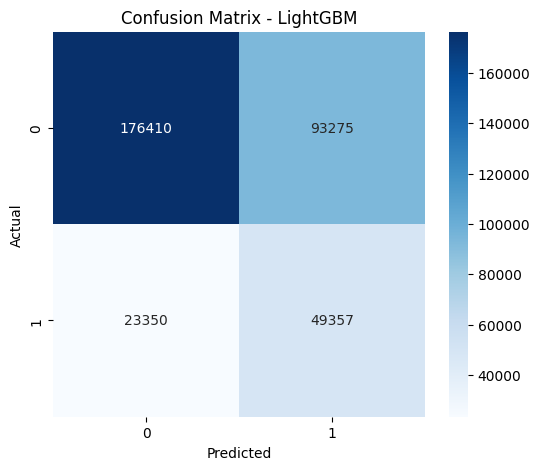

In [30]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_tree, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
print(classification_report(y_test, best_tree_preds))

              precision    recall  f1-score   support

           0       0.88      0.65      0.75    269685
           1       0.35      0.68      0.46     72707

    accuracy                           0.66    342392
   macro avg       0.61      0.67      0.60    342392
weighted avg       0.77      0.66      0.69    342392



In [32]:
tree_score_output = X_test.copy()
tree_score_output["actual_default"] = y_test.values
tree_score_output["predicted_pd_tree_model"] = best_model_probs
tree_score_output["predicted_default_050"] = best_tree_preds
tree_score_output["model_name"] = best_model_name

tree_score_output.to_csv("../data/outputs/tree_model_score_output.csv", index=False)

tree_score_output.head()

,loan_amnt,term_months,int_rate,installment,grade,sub_grade,grade_risk_numeric,emp_length_years,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,issue_year,issue_month,credit_history_months,loan_income_ratio,installment_income_ratio,high_dti_flag,high_revol_util_flag,recent_inquiry_flag,long_term_flag,income_band,dti_band,credit_history_band,actual_default,predicted_pd_tree_model,predicted_default_050,model_name
1369478,10000.0,36,10.49,324.98,B,B3,2,10.0,MORTGAGE,62000.0,Not Verified,debt_consolidation,9.50,0.0,0.0,16.0,1.0,8056.0,26.2,53.0,Individual,1.0,1.0,2016,10,289.0,0.161290,0.062899,0,0,0,0,Middle Income,Low DTI,Long Credit History,0,0.334686,0,LightGBM
319065,4000.0,36,12.69,134.18,C,C2,3,10.0,MORTGAGE,102000.0,Not Verified,home_improvement,18.24,0.0,0.0,8.0,0.0,7132.0,52.4,10.0,Individual,2.0,0.0,2015,3,83.0,0.039216,0.015786,0,0,0,0,Upper Middle Income,Moderate DTI,Moderate Credit History,0,0.301948,0,LightGBM
1321575,22400.0,60,18.99,580.95,D,D3,4,10.0,MORTGAGE,70000.0,Not Verified,credit_card,25.72,0.0,1.0,7.0,1.0,11386.0,40.4,22.0,Individual,3.0,1.0,2016,12,279.0,0.320000,0.099591,0,0,0,1,Middle Income,High DTI,Long Credit History,0,0.639001,1,LightGBM
900477,10000.0,36,10.99,327.34,B,B2,2,0.0,RENT,70000.0,Not Verified,debt_consolidation,17.59,0.0,1.0,13.0,0.0,10130.0,39.2,17.0,Individual,0.0,0.0,2014,1,100.0,0.142857,0.056115,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.278931,0,LightGBM
675610,5000.0,36,9.17,159.40,B,B2,2,0.0,OWN,62000.0,Source Verified,debt_consolidation,15.18,0.0,0.0,6.0,0.0,5129.0,68.4,12.0,Individual,1.0,0.0,2016,1,101.0,0.080645,0.030852,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.261981,0,LightGBM


,feature,importance
17,issue_year,817
12,revol_bal,572
13,revol_util,547
2,int_rate,532
19,credit_history_months,502
6,annual_inc,492
0,loan_amnt,431
7,dti,423
10,open_acc,420
20,loan_income_ratio,398


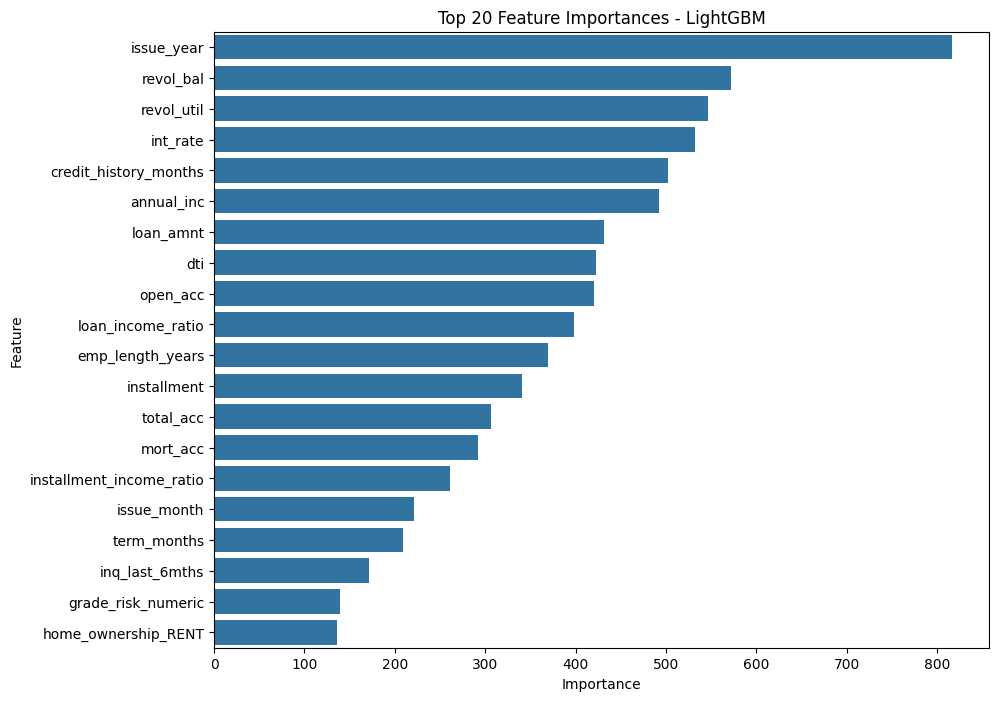

In [33]:
fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_classifier = best_model.named_steps["model"]

encoded_cat_features = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + encoded_cat_features.tolist()

if hasattr(fitted_classifier, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": all_feature_names,
        "importance": fitted_classifier.feature_importances_
    }).sort_values("importance", ascending=False)

    display(importance_df.head(30))

    importance_df.to_csv("../data/outputs/tree_model_feature_importance.csv", index=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=importance_df.head(20), x="importance", y="feature")
    plt.title(f"Top 20 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()
else:
    print("Selected model does not expose feature_importances_.")

# Tree Model Summary

## Key Actions Completed

- Built a decision tree model.
- Built a random forest model.
- Tested gradient boosting / LightGBM / XGBoost where available.
- Compared tree-based models against logistic regression benchmarks.
- Selected the strongest tree-based model based on ranking performance and classification metrics.
- Generated a confusion matrix and classification report.
- Saved prediction outputs and model artifact.
- Extracted feature importance for business interpretation.

## Business Interpretation

Tree-based models can capture non-linear relationships between borrower characteristics and default risk. These models are useful for improving predictive performance, while logistic regression remains useful as an explainable benchmark.

The final champion model should not be selected using ROC-AUC alone. It should also consider precision, recall, PR-AUC, calibration, interpretability, and how the model will be used in underwriting or portfolio monitoring.

## Next Step

The next notebook will perform deeper model evaluation using lift charts, decile analysis, Gini coefficient, KS statistic, calibration curves, and threshold tuning.